# 02 — EDA & Correlation Analysis
Isolate Masters Tournament history from the Kaggle CSV, explore SG distributions, and compute correlations with finishing position.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
FIGURES = Path('../outputs/figures')
CSV_OUT = Path('../outputs/csv')

## 1. Load & clean the Kaggle CSV

In [2]:
raw = pd.read_csv('../data/raw/ASA All PGA Raw Data - Tourn Level.csv')

# Drop junk unnamed columns
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')]

print(f'Full dataset: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
raw.head(2)

Full dataset: 36,864 rows × 34 columns


,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,purse,season,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
0,A. Ancer,401353224,9261,288,289,60.0,51.1,56,3,7.6,...,12.0,2022,0,T32,0.20,-0.13,-0.08,0.86,0.65,0.85
1,A. Hadwin,401353224,5548,288,286,72.5,61.5,61,8,13.0,...,12.0,2022,0,T18,0.36,0.75,0.31,0.18,1.24,1.60


## 2. Isolate Masters rows

In [3]:
masters = raw[raw['tournament name'].str.contains('Masters', case=False, na=False)].copy()

print(f'Masters rows: {len(masters)}')
print(f'Years covered: {sorted(masters["season"].unique())}')
print(f'Unique players: {masters["player"].nunique()}')
masters.head(3)

Masters rows: 660
Years covered: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022)]
Unique players: 213


,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,purse,season,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
878,A. Ancer,401353232,9261,144,151,23.0,13.7,18,0,6.4,...,15.0,2022,0,CUT,2.72,-2.87,-1.39,0.25,-4.00,-1.28
879,A. Scott,401353232,388,288,302,43.5,28.4,38,0,1.2,...,15.0,2022,0,T48,-0.11,-0.63,-0.60,-0.31,-1.54,-1.65
880,B. DeChambeau,401353232,10046,144,156,12.0,1.8,12,0,0.2,...,15.0,2022,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Prepare numeric finish position
The `pos` column is numeric finish position (NaN for cuts). We'll use it as the target.
Missed cuts get a penalty position (field size + 1) so they sort to the bottom.

In [4]:
# field size per year for penalty
field_size = masters.groupby('season')['player'].count()

def assign_finish(row):
    if pd.notna(row['pos']):
        return row['pos']
    return field_size[row['season']] + 1

masters['finish_pos'] = masters.apply(assign_finish, axis=1)

print('finish_pos sample (made_cut=0 should have large values):')
print(masters[['player', 'season', 'made_cut', 'Finish', 'pos', 'finish_pos']].head(10).to_string())

finish_pos sample (made_cut=0 should have large values):
                      player  season  made_cut Finish   pos  finish_pos
878            Abraham Ancer    2022         0    CUT   NaN        85.0
879               Adam Scott    2022         1    T48  48.0        48.0
880        Bryson DeChambeau    2022         0    NaN   NaN        85.0
881             Brian Harman    2022         0    CUT   NaN        85.0
882           Billy Horschel    2022         1     43  43.0        43.0
883            Brooks Koepka    2022         0    CUT   NaN        85.0
884          Bernhard Langer    2022         0    CUT   NaN        85.0
885             Bubba Watson    2022         1    T39  39.0        39.0
886  Christiaan Bezuidenhout    2022         1    T44  44.0        44.0
887            Cameron Champ    2022         1    T10  10.0        10.0


## 4. SG column distributions + stats + correlation with finish

sg_putt       mean=-0.054  median=-0.025  std=1.106  95% CI=[-0.300, +0.191]  r_with_finish=-0.305  p=0.0067
sg_arg        mean=-0.043  median=-0.110  std=0.809  95% CI=[-0.223, +0.136]  r_with_finish=-0.390  p=0.0004
sg_app        mean=-0.082  median=+0.040  std=1.060  95% CI=[-0.317, +0.154]  r_with_finish=-0.608  p=0.0000
sg_ott        mean=-0.028  median=+0.055  std=0.829  95% CI=[-0.212, +0.156]  r_with_finish=-0.370  p=0.0008
sg_t2g        mean=-0.153  median=-0.035  std=1.829  95% CI=[-0.559, +0.253]  r_with_finish=-0.693  p=0.0000
sg_total      mean=-0.209  median=-0.020  std=1.949  95% CI=[-0.642, +0.223]  r_with_finish=-0.823  p=0.0000
made_cut      mean=+0.659  median=+1.000  std=0.474  95% CI=[+0.623, +0.695]  r_with_finish=-0.800  p=0.0000


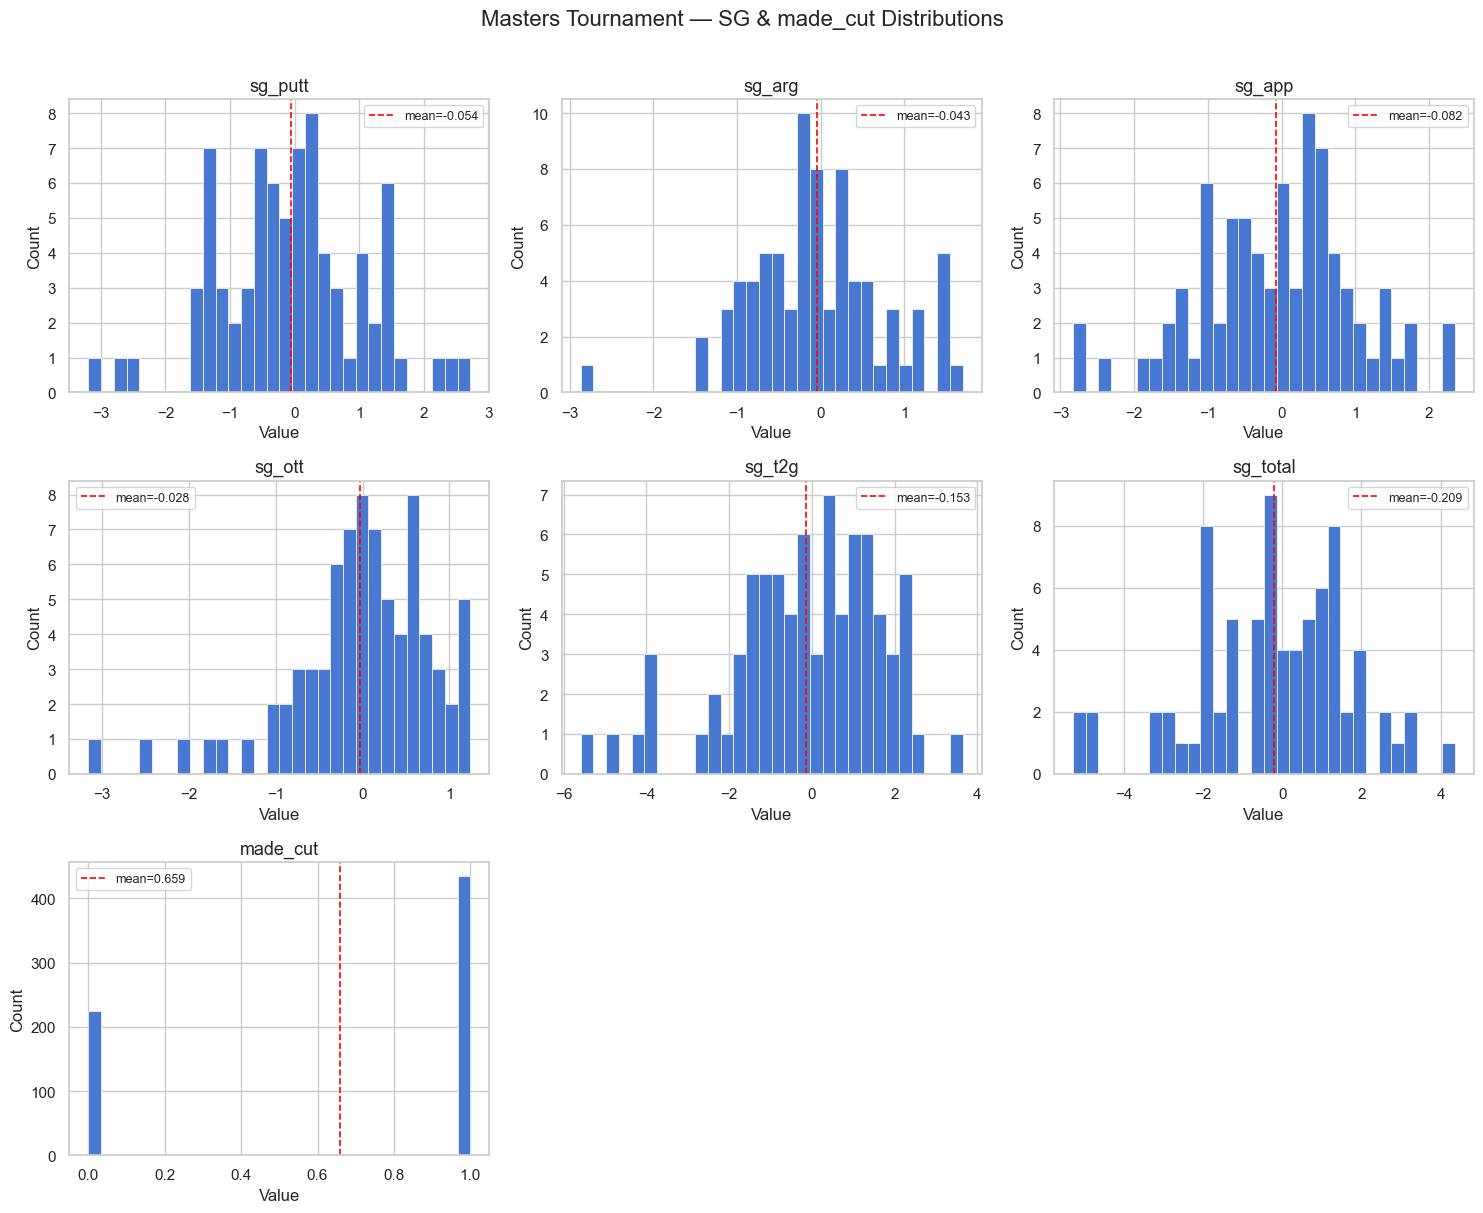

Saved: outputs/figures/sg_distributions.png


In [5]:
sg_cols = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'sg_total']
extra_cols = ['made_cut']
analysis_cols = sg_cols + extra_cols

stats_rows = []

n_cols = 3
n_rows = int(np.ceil(len(analysis_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(analysis_cols):
    series = masters[col].dropna()
    ax = axes[i]

    ax.hist(series, bins=30, edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontsize=13)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

    mean = series.mean()
    median = series.median()
    std = series.std()
    n = len(series)
    se = std / np.sqrt(n)
    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se

    # Pearson r with finish_pos (only rows where both are non-null)
    valid = masters[[col, 'finish_pos']].dropna()
    if len(valid) > 2:
        r, p = stats.pearsonr(valid[col], valid['finish_pos'])
    else:
        r, p = np.nan, np.nan

    ax.axvline(mean, color='red', linestyle='--', linewidth=1.2, label=f'mean={mean:.3f}')
    ax.legend(fontsize=9)

    print(f'{col:12s}  mean={mean:+.3f}  median={median:+.3f}  std={std:.3f}  '
          f'95% CI=[{ci_low:+.3f}, {ci_high:+.3f}]  r_with_finish={r:+.3f}  p={p:.4f}')

    stats_rows.append({'variable': col, 'mean': mean, 'median': median, 'std': std,
                       'ci_low_95': ci_low, 'ci_high_95': ci_high,
                       'pearson_r_vs_finish': r, 'p_value': p})

# hide any unused subplot panels
for j in range(len(analysis_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Masters Tournament — SG & made_cut Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'sg_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/sg_distributions.png')

## 5. Correlation heatmap — all numeric variables vs finish_pos

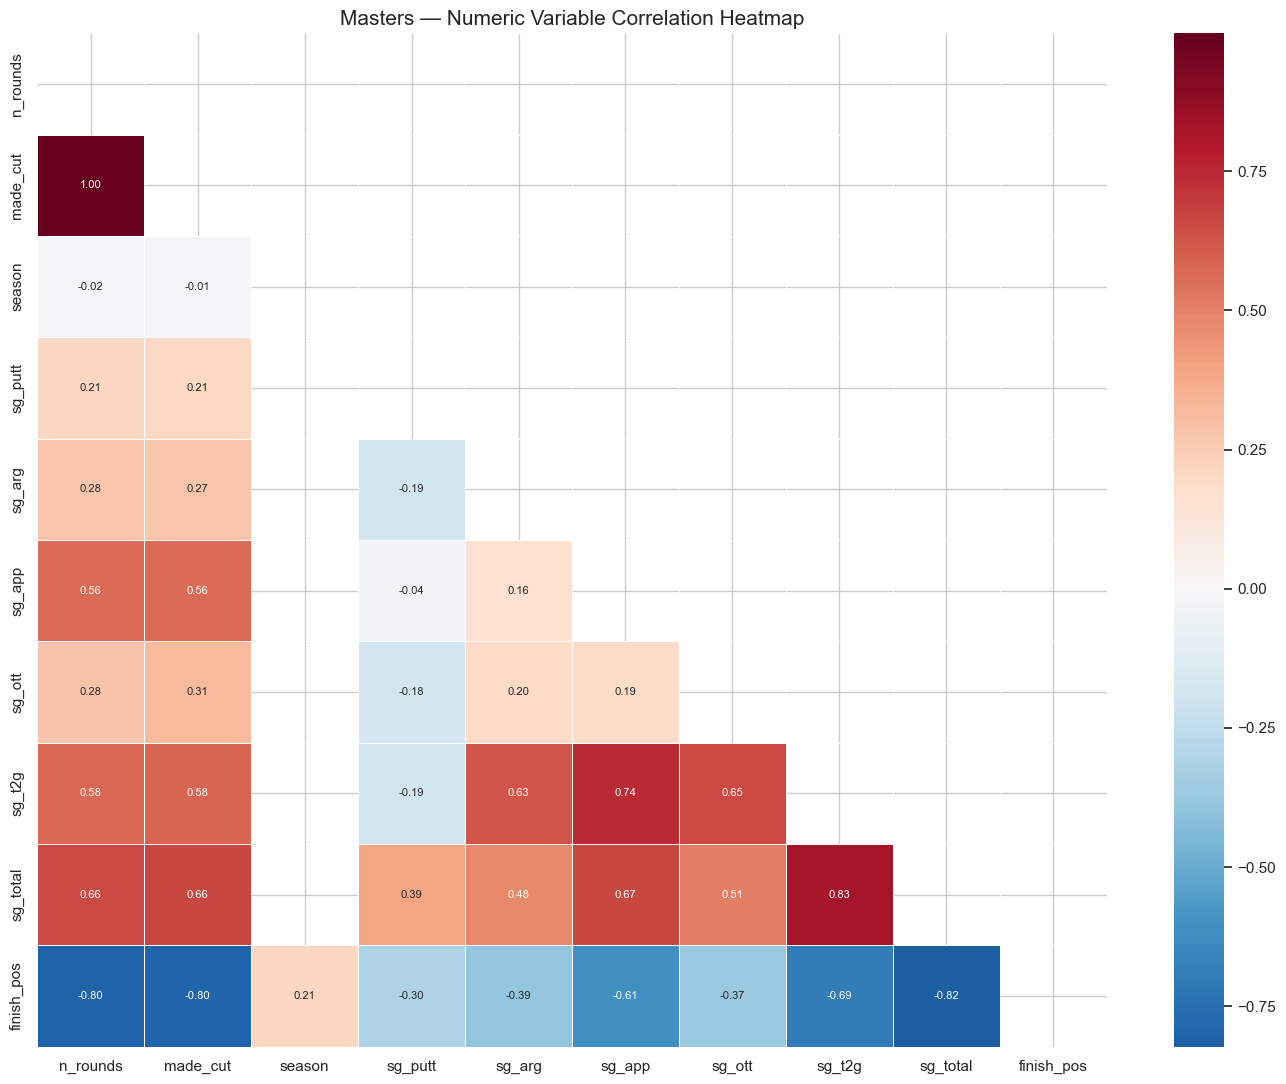

Saved: outputs/figures/correlation_heatmap.png


In [6]:
numeric_cols = masters.select_dtypes(include='number').columns.tolist()
# remove id-like / scoring-system / redundant columns
drop_cols = ['tournament id', 'player id', 'hole_par', 'strokes',
             'hole_DKP', 'hole_FDP', 'hole_SDP',
             'streak_DKP', 'streak_FDP', 'streak_SDP',
             'finish_DKP', 'finish_FDP', 'finish_SDP',
             'total_DKP', 'total_FDP', 'total_SDP',
             'pos', 'purse', 'no_cut']
heatmap_cols = [c for c in numeric_cols if c not in drop_cols]

corr_df = masters[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Masters — Numeric Variable Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/correlation_heatmap.png')

## 6. Top 5 predictors of Masters finish position

In [7]:
# Correlations with finish_pos specifically
finish_corr = corr_df['finish_pos'].drop('finish_pos').sort_values(key=abs, ascending=False)

print('Top 10 variables correlated with Masters finish_pos (|r|, descending):')
print(finish_corr.head(10).to_string())

print('\nTop 5 predictors:')
for rank, (var, r) in enumerate(finish_corr.head(5).items(), 1):
    direction = 'lower finish (better)' if r < 0 else 'higher finish (worse)'
    print(f'  {rank}. {var:15s}  r={r:+.3f}  → higher {var} → {direction}')

Top 10 variables correlated with Masters finish_pos (|r|, descending):
sg_total   -0.822558
n_rounds   -0.802242
made_cut   -0.800466
sg_t2g     -0.693472
sg_app     -0.608102
sg_arg     -0.390235
sg_ott     -0.370385
sg_putt    -0.304839
season      0.209780

Top 5 predictors:
  1. sg_total         r=-0.823  → higher sg_total → lower finish (better)
  2. n_rounds         r=-0.802  → higher n_rounds → lower finish (better)
  3. made_cut         r=-0.800  → higher made_cut → lower finish (better)
  4. sg_t2g           r=-0.693  → higher sg_t2g → lower finish (better)
  5. sg_app           r=-0.608  → higher sg_app → lower finish (better)


## 7. Save correlation results

In [8]:
corr_df.to_csv(CSV_OUT / 'correlation_matrix.csv')
print('Saved: outputs/csv/correlation_matrix.csv')

# Also save the per-variable summary stats
stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(CSV_OUT / 'sg_stats_summary.csv', index=False)
print('Saved: outputs/csv/sg_stats_summary.csv')

stats_df

Saved: outputs/csv/correlation_matrix.csv
Saved: outputs/csv/sg_stats_summary.csv


,variable,mean,median,std,ci_low_95,ci_high_95,pearson_r_vs_finish,p_value
0,sg_putt,-0.054231,-0.025,1.105549,-0.299581,0.191120,-0.304839,6.653379e-03
1,sg_arg,-0.043333,-0.110,0.809206,-0.222917,0.136251,-0.390235,4.125019e-04
2,sg_app,-0.081795,0.040,1.060409,-0.317127,0.153538,-0.608102,3.528512e-09
3,sg_ott,-0.027692,0.055,0.829384,-0.211754,0.156370,-0.370385,8.441553e-04
4,sg_t2g,-0.152692,-0.035,1.828839,-0.558560,0.253175,-0.693472,1.961992e-12
5,sg_total,-0.209487,-0.020,1.949235,-0.642074,0.223099,-0.822558,2.584411e-20
6,made_cut,0.659091,1.000,0.474374,0.622900,0.695282,-0.800466,2.070905e-148
